In [ ]:

!pip install transformer-lens circuitsvis -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 968.6/968.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.6 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from collections import Counter
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load GPT-2 Small
model = HookedTransformer.from_pretrained(
    "gpt2-small",
    device=device
)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


In [ ]:
induction_heads = [
    (5, 5),
    (7, 10),
    (5, 1),
    (6, 9),
    (7, 2),
    (5, 0),
    (10, 7),
    (8, 1),
    (10, 1),
    (9, 9)
]

prompts = [


    "The capital of India is",
    "The largest planet in the solar system is",

    "Once upon a time there was",
    "In a distant galaxy humanity discovered",


    "The reason climate change is difficult to solve is",
    "Artificial intelligence may become dangerous if",


    "Alice went to Paris. Bob went to London. Alice went to",
    "The cat sat on the mat. The dog sat on the",

    "The true meaning of life is",
    "Materialistic Wealth is not sufficient"
]

In [ ]:
def local_repetition_rate(text, window_size=20):
    words = text.split()

    if len(words) < window_size:
        return 0

    repeated = 0
    total = 0

    for i in range(window_size, len(words)):
        current_word = words[i]

        previous_window = words[i-window_size:i]

        if current_word in previous_window:
            repeated += 1

        total += 1

    return repeated / total if total > 0 else 0


In [ ]:
def generate_text(model, prompt, max_new_tokens=100):


    tokens = model.to_tokens(prompt).to(device)


    output_tokens = model.generate(
        tokens,
        max_new_tokens=max_new_tokens,
        temperature=1.0,
        freq_penalty=0.0,
        stop_at_eos=False,
        verbose=False
    )

    text = model.to_string(output_tokens[0])

    return text

In [ ]:
def head_ablation_hook(value, hook, heads_to_ablate):
    value = value.clone()

    for head in heads_to_ablate:
        value[:, :, head, :] = 0

    return value



In [ ]:
num_heads_list = []

mean_delta_lrrs = []

std_delta_lrrs = []


for n in range(1, len(induction_heads) + 1):

    print(f"\n==============================")
    print(f"Ablating {n} induction heads")
    print(f"==============================")

    heads_subset = induction_heads[:n]

    delta_lrrs = []


    fwd_hooks = []

    for layer, head in heads_subset:

        hook_fn = lambda value, hook, h=head: head_ablation_hook(
            value,
            hook,
            [h]
        )

        fwd_hooks.append(
            (f"blocks.{layer}.attn.hook_z", hook_fn)
        )


    for prompt in tqdm(prompts):

        baseline_text = generate_text(model, prompt)

        baseline_lrr = local_repetition_rate(
            baseline_text
        )


        with model.hooks(fwd_hooks=fwd_hooks):

            ablated_text = generate_text(
                model,
                prompt
            )

        ablated_lrr = local_repetition_rate(
            ablated_text
        )

        delta_lrr = ablated_lrr - baseline_lrr

        delta_lrrs.append(delta_lrr)

    mean_delta = np.mean(delta_lrrs)

    std_delta = np.std(delta_lrrs)

    num_heads_list.append(n)

    mean_delta_lrrs.append(mean_delta)

    std_delta_lrrs.append(std_delta)

    print(f"\nMean ΔLRR: {mean_delta:.4f}")
    print(f"Std ΔLRR : {std_delta:.4f}")



Ablating 1 induction heads


100%|██████████| 10/10 [00:51<00:00,  5.13s/it]



Mean ΔLRR: -0.0066
Std ΔLRR : 0.0807

Ablating 2 induction heads


100%|██████████| 10/10 [00:51<00:00,  5.10s/it]



Mean ΔLRR: 0.0782
Std ΔLRR : 0.1066

Ablating 3 induction heads


...


Mean ΔLRR: 0.1547
Std ΔLRR : 0.1323

Ablating 9 induction heads


100%|██████████| 10/10 [00:51<00:00,  5.12s/it]



Mean ΔLRR: 0.1060
Std ΔLRR : 0.1031

Ablating 10 induction heads


100%|██████████| 10/10 [00:51<00:00,  5.18s/it]


Mean ΔLRR: 0.0705
Std ΔLRR : 0.1042


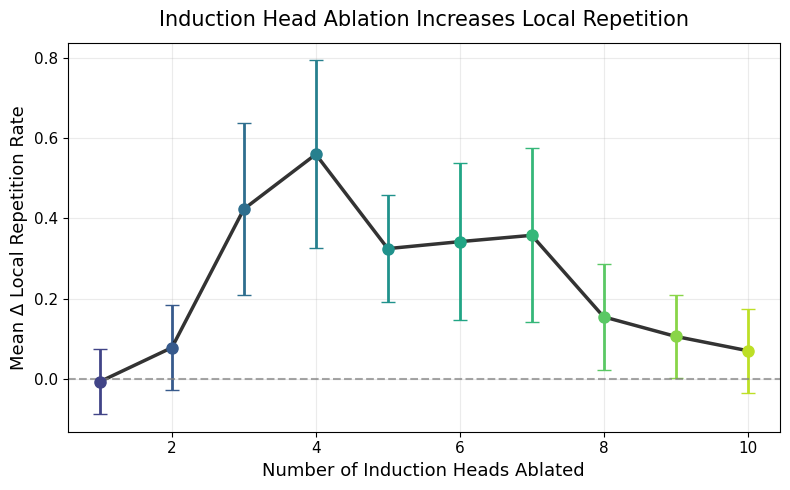

In [ ]:
plt.figure(figsize=(8,5))

cmap = plt.cm.viridis

colors = cmap(
    np.linspace(
        0.2,
        0.9,
        len(num_heads_list)
    )
)

for i in range(len(num_heads_list)):

    plt.errorbar(
        num_heads_list[i],
        mean_delta_lrrs[i],
        yerr=std_delta_lrrs[i],
        fmt='o',
        color=colors[i],
        markersize=8,
        capsize=5,
        elinewidth=2
    )

plt.plot(
    num_heads_list,
    mean_delta_lrrs,
    linewidth=2.5,
    color='black',
    alpha=0.8
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1.5,
    color='gray',
    alpha=0.7
)

plt.xlabel(
    "Number of Induction Heads Ablated",
    fontsize=13
)

plt.ylabel(
    "Mean Δ Local Repetition Rate",
    fontsize=13
)

plt.title(
    "Induction Head Ablation Increases Local Repetition",
    fontsize=15,
    pad=12
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()